In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.metrics import mean_squared_error,r2_score
from sklearn.model_selection import TimeSeriesSplit
import xgboost as xgb

import cudf,os
import optuna

In [11]:
os.chdir('/projects/data_mining_project')

In [12]:
np.set_printoptions(suppress=True, precision=3) ## for disabling numpy scientific representation

In [13]:
csv_path = "New Emission.csv"
df = pd.read_csv(csv_path)
df['Date'] = pd.to_datetime(df['Year'].astype(str) + '-' + df['Month'].astype(str).str.zfill(2))
df.set_index('Date', inplace=True)
df.head(2)

,CO2 Emission,Year,Month
Date,,,
1973-01-01,106.363,1973,1
1973-02-01,101.760,1973,2


In [14]:
cdf_frame = cudf.DataFrame.from_pandas(df)

In [ ]:
fig, axis = plt.subplots(figsize=(20,8))
sns.boxplot(data=df,x="Year",y="CO2 Emission")
axis.set_title("CO2 By Years")

In [ ]:
fig, axis = plt.subplots(figsize=(20,8))
sns.boxplot(data=df,hue="Year",y="CO2 Emission")
axis.set_title("CO2 By Years")

In [ ]:
fig, axis = plt.subplots(figsize=(20,8))
sns.boxplot(data=df,hue="Month",y="CO2 Emission",legend=False)
axis.set_title("CO2 By Years")

In [15]:
train_size = int(len(cdf_frame) * 0.8)
train,test = cdf_frame[:train_size],cdf_frame[train_size:]
features = ['Year', 'Month']
target = ['CO2 Emission']
x_train,y_train = train[features],train[target]
x_test,y_test = test[features],test[target]
splits = 5

In [65]:
base_params = {
    'tree_method': 'hist',
    'device': 'cuda',
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse'
}

In [79]:
def objective(trial):
    n_estimators = trial.suggest_int('n_estimators',80,90,step=1)
    booster = trial.suggest_categorical('booster',["gbtree","dart"])
    learning_rate = trial.suggest_float('learning_rate',0.1,0.2,step=0.005)
    max_depth = trial.suggest_int('max_depth',2,5,step=1)
    reg_lambda = trial.suggest_float('reg_lambda',1.2,1.6,step=0.1)
    reg_alpha = trial.suggest_float('reg_alpha',0.8,1.2,step=0.2)
    
    additional_params = {
        'n_estimators':n_estimators,
        'booster':booster,
        'learning_rate':learning_rate,
        'max_depth':max_depth,
        'reg_lambda':reg_lambda,
        'reg_alpha':reg_alpha
    }
    
    xgb_model = xgb.XGBRegressor(**base_params,**additional_params)
    xgb_model.fit(x_train,y_train)
    
    kf = TimeSeriesSplit(n_splits=splits)
    scores = []
    for train_idx, val_idx in kf.split(x_train):
        X_tr = x_train.iloc[train_idx]
        X_val = x_train.iloc[val_idx]
        y_tr = y_train.iloc[train_idx]
        y_val = y_train.iloc[val_idx]

        xgb_model.fit(X_tr, y_tr)
        preds = xgb_model.predict(X_val)
        mse = ((preds - y_val.to_numpy()) ** 2).mean()
        scores.append(-mse)
    return np.mean(scores)

In [80]:
study = optuna.create_study(direction="maximize",sampler=optuna.samplers.RandomSampler())
study.optimize(objective, n_trials=100,timeout=2000,n_jobs=4)

[I 2025-05-08 12:45:25,585] A new study created in memory with name: no-name-9d588bfe-8eda-4e92-8825-e099867d2e33
[I 2025-05-08 12:45:29,346] Trial 3 finished with value: -117.52766762190734 and parameters: {'n_estimators': 85, 'booster': 'gbtree', 'learning_rate': 0.14500000000000002, 'max_depth': 2, 'reg_lambda': 1.2, 'reg_alpha': 1.2}. Best is trial 3 with value: -117.52766762190734.
[I 2025-05-08 12:45:29,546] Trial 0 finished with value: -118.7065583034771 and parameters: {'n_estimators': 85, 'booster': 'gbtree', 'learning_rate': 0.125, 'max_depth': 3, 'reg_lambda': 1.2, 'reg_alpha': 1.2}. Best is trial 3 with value: -117.52766762190734.
[I 2025-05-08 12:45:29,725] Trial 1 finished with value: -118.86355002082583 and parameters: {'n_estimators': 88, 'booster': 'gbtree', 'learning_rate': 0.2, 'max_depth': 3, 'reg_lambda': 1.2, 'reg_alpha': 1.0}. Best is trial 3 with value: -117.52766762190734.
[I 2025-05-08 12:45:33,954] Trial 5 finished with value: -117.88732179284379 and paramete

In [81]:
study.best_trial

FrozenTrial(number=2, state=1, values=[-116.00408207995952], datetime_start=datetime.datetime(2025, 5, 8, 12, 45, 25, 592551), datetime_complete=datetime.datetime(2025, 5, 8, 12, 46, 57, 662101), params={'n_estimators': 82, 'booster': 'dart', 'learning_rate': 0.125, 'max_depth': 2, 'reg_lambda': 1.2, 'reg_alpha': 0.8}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'n_estimators': IntDistribution(high=90, log=False, low=80, step=1), 'booster': CategoricalDistribution(choices=('gbtree', 'dart')), 'learning_rate': FloatDistribution(high=0.2, log=False, low=0.1, step=0.005), 'max_depth': IntDistribution(high=5, log=False, low=2, step=1), 'reg_lambda': FloatDistribution(high=1.6, log=False, low=1.2, step=0.1), 'reg_alpha': FloatDistribution(high=1.2, log=False, low=0.8, step=0.2)}, trial_id=2, value=None)

In [82]:
best_params = study.best_params
best_params

{'n_estimators': 82,
 'booster': 'dart',
 'learning_rate': 0.125,
 'max_depth': 2,
 'reg_lambda': 1.2,
 'reg_alpha': 0.8}

**current params**
{'n_estimators': 70,
 'booster': 'gbtree',
 'learning_rate': 0.03,
 'max_depth': 3,
 'reg_lambda': 0.9}
- mse : 75.15186523223853
- r2  : 0.15828004981335908
---
**another run**
{'n_estimators': 84,
 'booster': 'gbtree',
 'learning_rate': 0.05,
 'max_depth': 5,
 'reg_lambda': 1.5}
- mse : 67.35618440503069
- r2  : 0.24559365217400253
---
**another run**
{'n_estimators': 84,
 'booster': 'gbtree',
 'learning_rate': 0.11499999999999999,
 'max_depth': 2,
 'reg_lambda': 1.4,
 'reg_alpha': 0.8}
- mse : 65.80324752459973
- r2  : 0.2629869390817853

In [83]:
xgb_model = xgb.XGBRegressor(**base_params,**best_params)
xgb_model.fit(x_train,y_train)
y_pred = xgb_model.predict(x_test)
y_true = y_test.to_numpy()
mse = mean_squared_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)
print(mse)
print(r2)

67.07621602145312
0.24872936907404897


<Axes: title={'center': 'Feature Importances of our booster'}>

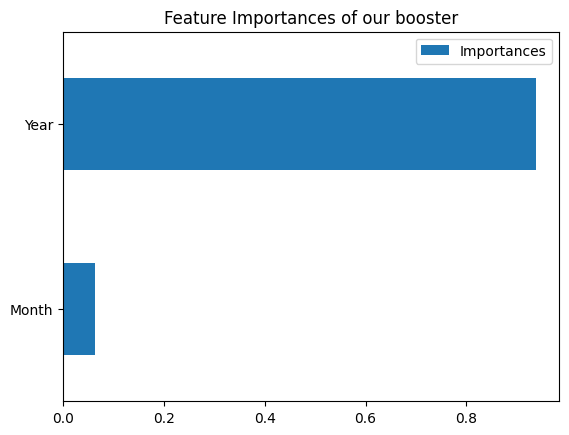

In [84]:
fi = pd.DataFrame(
    data=xgb_model.feature_importances_,index=xgb_model.feature_names_in_,columns=["Importances"]
)

fi.sort_values(by="Importances").plot(kind='barh',title='Feature Importances of our booster')